# **🏢Pipelines: Predictions of Attrition of HR Employees**


# **M505A Intro to AI and Machine(WS1225) - Individual Project**

# **Gisma University of Applied Sciences**

# **Company Scenario**
* TechCorp Solution is a mid-sized tech firm having 1470 employees operating under three divisions namely Sales, Research and Development, and Human Resources. The HR department has been observing an increasing trend of concern - employee turnover has been increasing costing them an estimated $15000-$25000 per lost employee in the recruitment, onboarding and unproductive nature. The HR VP is willing to employ data driven machine learning to proactively detect employees who are at risk of leaving the company before they quit.
* Purpose: Develop and test several ML Models to predict employee turnover (Yes/No) based on HR data, and thus have TechCrop HR Team intervene early- retention bonus, role shift, workload, etc. to reduce voluntary turnover by at least 20%.

# **1. Importing Libraries**
This step introduces the important libraries which will help to construct data, as well as help with the data.  
* pandas: to read and manipulate data
* seaborn: graphs
* sklearn: to divide data, to build ML models and checking its Accuracy
* StandardScalar: to normalise the features in KNN and Logistic Regression

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# **2. Loading the Dataset**
After that, the HR Employe Attrition Dataset is loaded through CSV file and the initial three rows are presented to have a quick look.

In [2]:
df1 = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df1.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


# **3. Elimination of Irrelevant Columns**
This move removes the columns that do not form an analysis.This is because either they have a constant value or are just identifiers, which would not be useful in the prediction.

In [3]:
df1 = df1.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])

# **4. Verifying the Changes**
The step shows the first five rows of the dataset to make sure that the irrelevant columns are already removed and that the rest of the data looks the way it is supposed to be.

In [4]:
df1.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


# **5. Checking Dimensions**
This is done to provide a rapid validation of the existing size of the dataset.

In [5]:
df1.shape

(1470, 31)

# **6. The Choice of Relevant Features**
The step will create a new dataframe that will only have the columns that are the most likely to bring useful informstion in the analysis of employee burnout and attrition. These are the features that are chosen as they are likely to directly impact on stress and turnover of employee.

In [6]:
df1_burnout = df1[['BusinessTravel', 'TotalWorkingYears', 'WorkLifeBalance', 'OverTime', 'DistanceFromHome', 'Department', 'Attrition', 'JobInvolvement', 'Gender']].copy()

df1_burnout.head(3)

,BusinessTravel,TotalWorkingYears,WorkLifeBalance,OverTime,DistanceFromHome,Department,Attrition,JobInvolvement,Gender
0,Travel_Rarely,8,1,Yes,1,Sales,Yes,3,Female
1,Travel_Frequently,10,3,No,8,Research & Development,No,2,Male
2,Travel_Rarely,7,3,Yes,2,Research & Development,Yes,2,Male


# **7. Data Visualisation**
The following section examines the correlation of all these factors and employee attrition using the visual charts:
*   **Overtime** **vs** **Attrition**: A count plot to demonstrate the effect of the overtime on the employee turnover.
*   **Business** **Travel** **vs** **Attrition** **Rate**: A The bar chart will show the attrition percentage in the various categories of business travels.
*  **Work-Life Balance vs** **Total Working** **Years:** Using a boxplot to investigate whether experience and poor work-life balance.
*   **Work-Life Balance vs Attrition Rate:** A bar graph to display the percentage attrition by the various levels of work-life balance.
*   **Distance from Home vs Attrition:** A histogram used to indicate whether an increase in employee attrition is reported with distance of commute sidtance.
*   **Gender vs Attrition Rate:** A bar chart to indicate the attrition percentage in relation to various gender groups to determine whether gender is a contributing factor to the turnover of employees.
*   **Job Involvement vs Attrition:** The bar chart to determine whether employee attrition is high when job involvement is lower.








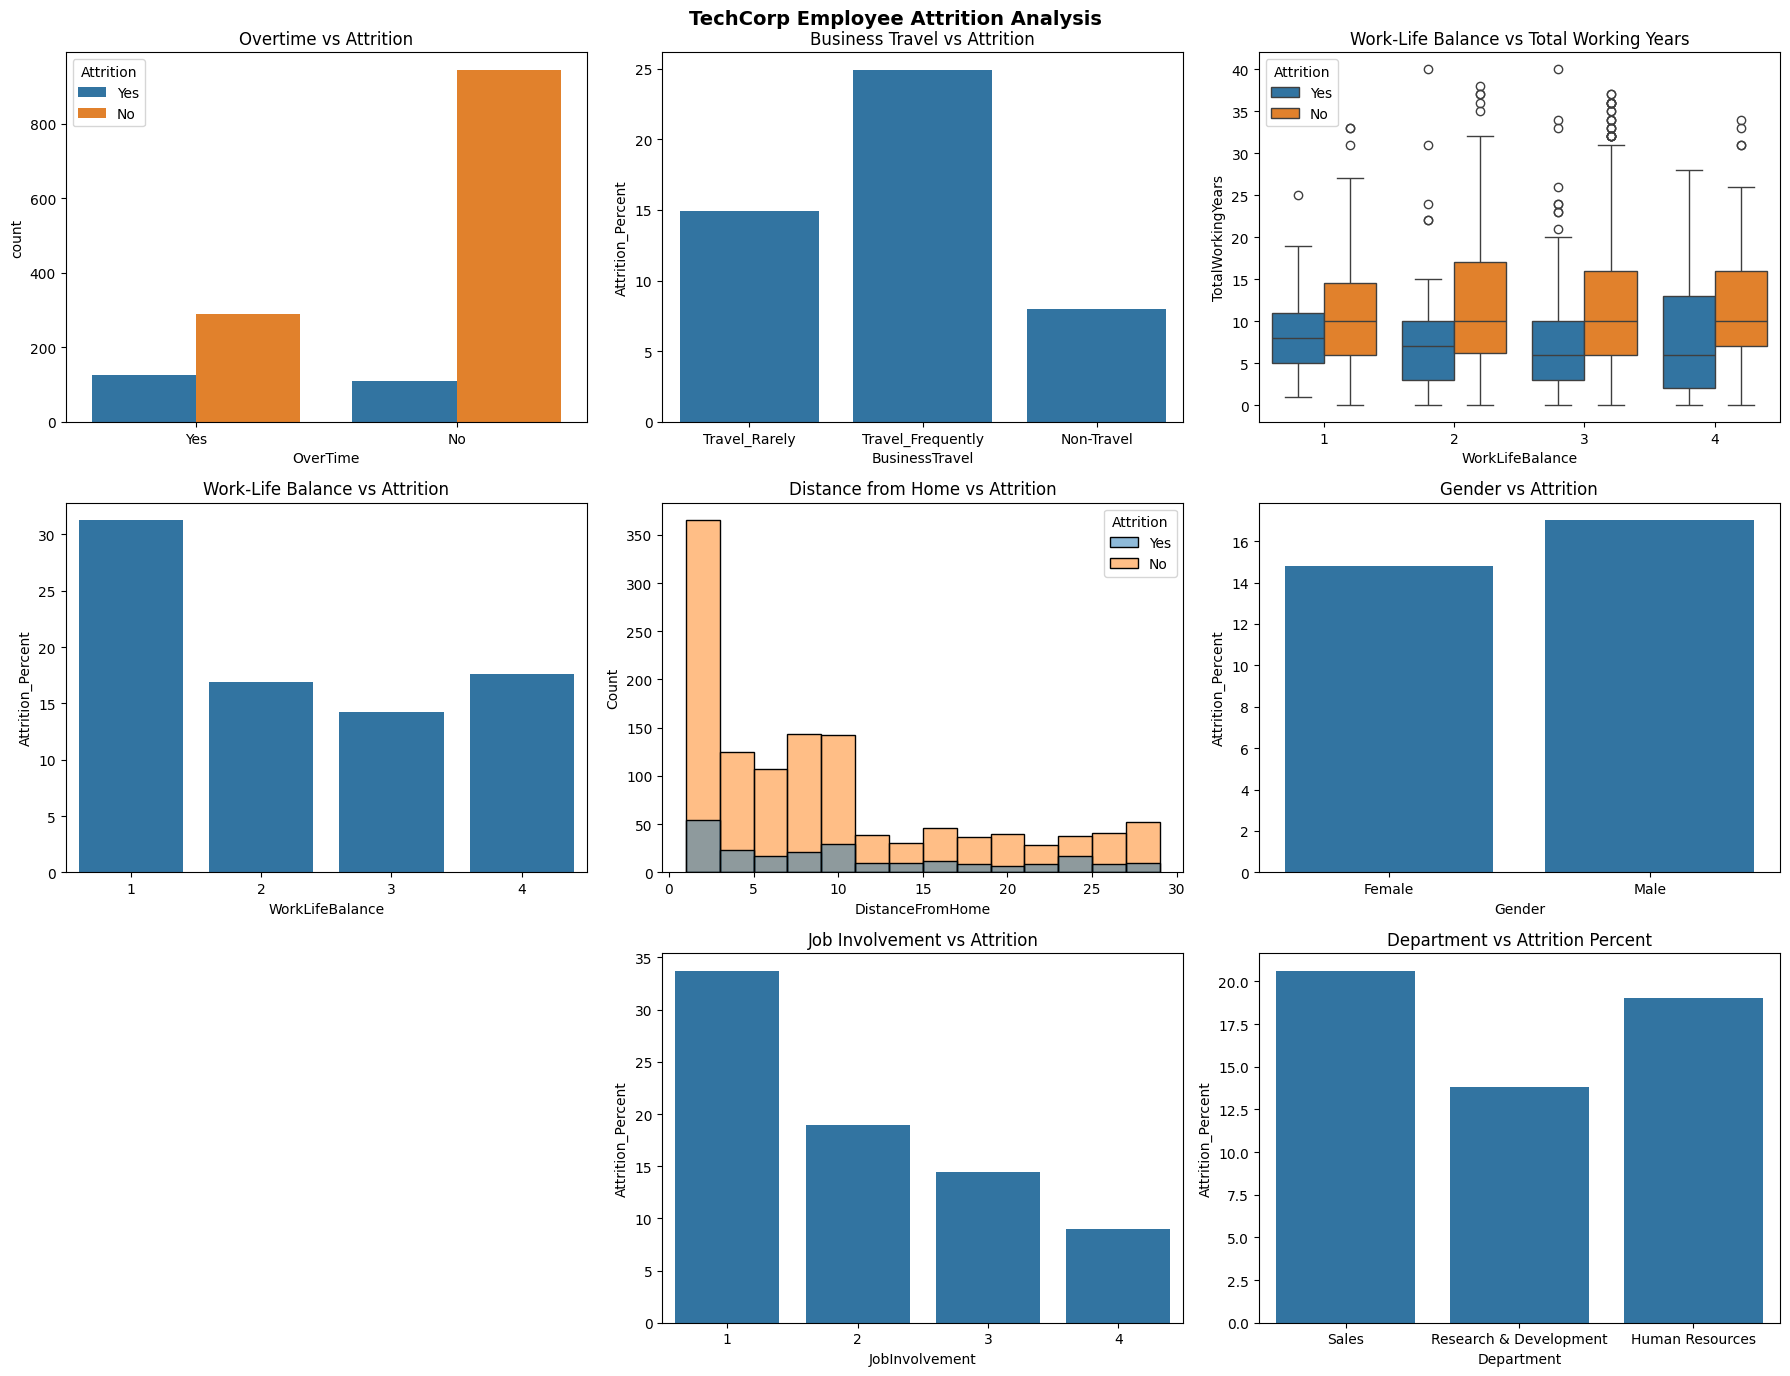

In [7]:
fig, axes = plt.subplots(3,3, figsize=(18,14))
fig.suptitle('TechCorp Employee Attrition Analysis', fontsize=14, fontweight= 'bold')

df1_burnout=df1_burnout.copy()
df1_burnout['Attrition_Percent'] = (df1_burnout['Attrition'] == 'Yes').astype(int) * 100

sns.countplot(x='OverTime', hue='Attrition', data=df1_burnout, ax=axes[0, 0])
axes[0, 0].set_title('Overtime vs Attrition')

sns.barplot(x='BusinessTravel', y='Attrition_Percent', data=df1_burnout, errorbar=None,ax=axes[0,1])
axes[0, 1].set_title('Business Travel vs Attrition')

sns.boxplot(x='WorkLifeBalance', y='TotalWorkingYears', hue='Attrition', data=df1_burnout, ax=axes[0,2])
axes[0, 2].set_title('Work-Life Balance vs Total Working Years')

sns.barplot(x='WorkLifeBalance', y='Attrition_Percent', data=df1_burnout, errorbar=None, ax=axes[1,0])
axes[1, 0].set_title('Work-Life Balance vs Attrition')

sns.histplot(x='DistanceFromHome', hue='Attrition', data=df1_burnout, ax=axes[1,1])
axes[1, 1].set_title('Distance from Home vs Attrition')

sns.barplot(x='Department', y='Attrition_Percent', data=df1_burnout, errorbar=None, ax=axes[2,2])
axes[2,2].set_title('Department vs Attrition Percent')

sns.barplot(x='Gender', y='Attrition_Percent', data=df1_burnout, errorbar=None, ax=axes[1,2])
axes[1, 2].set_title('Gender vs Attrition')

sns.barplot(x='JobInvolvement', y='Attrition_Percent', data=df1_burnout, errorbar=None, ax=axes[2,1])
axes[2,1].set_title('Job Involvement vs Attrition')

axes[2,0].axis('off')

plt.tight_layout()
plt.show()

# **8. Preparing Data (Model Building)**
Here:
*   **Target Variables:** The attrition column is converted into a numeric value where 1 is equivalent to staff who dropped out and 0 staff who remained.
*   **Feature Variables:** The other columns other than the ones Attrition and Attrition Percent are chosen as input features that will be used by the model in predicting.
*   **Encoding Categorical Variables:** Machine Learning Model only comprehend numbers, and therefore all text-based columns are transformed into 1s and 0s by One-Hot Encoding.

In [10]:
b = (df1_burnout['Attrition'] == 'Yes').astype(int)

A_words = df1_burnout[['BusinessTravel', 'TotalWorkingYears', 'WorkLifeBalance', 'OverTime', 'DistanceFromHome', 'Department', 'JobInvolvement', 'Gender']]

A = pd.get_dummies(A_words, drop_first=True)
print(A.columns.tolist)

A.head(7)

<bound method IndexOpsMixin.tolist of Index(['TotalWorkingYears', 'WorkLifeBalance', 'DistanceFromHome',
       'JobInvolvement', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'OverTime_Yes',
       'Department_Research & Development', 'Department_Sales', 'Gender_Male'],
      dtype='object')>


,TotalWorkingYears,WorkLifeBalance,DistanceFromHome,JobInvolvement,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,OverTime_Yes,Department_Research & Development,Department_Sales,Gender_Male
0,8,1,1,3,False,True,True,False,True,False
1,10,3,8,2,True,False,False,True,False,True
2,7,3,2,2,False,True,True,True,False,True
3,8,3,3,3,True,False,True,True,False,False
4,6,3,2,3,False,True,False,True,False,True
5,8,2,2,3,True,False,False,True,False,True
6,12,2,3,4,False,True,True,True,False,False


# **9. Building & Evaluating Machine Learning Models**
This step is comparing five machine learning models.

The score of accuracy of each model is obtained and printed to compare the level to which each one of the models forecasts employee attrition.

In [11]:
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.25, random_state=42)
# KNN and Logistic Regression
scaler = StandardScaler()
A_train_scaled = scaler.fit_transform(A_train)
A_test_scaled = scaler.transform(A_test)

print(f"Training Samples:{A_train.shape[0]}")
print(f"Testing Samples: {A_test.shape[0]}")

Training Samples:1102
Testing Samples: 368


In [12]:
robot_detective = DecisionTreeClassifier(random_state=42)

robot_detective.fit(A_train, b_train)

predictions = robot_detective.predict(A_test)

score = accuracy_score(b_test, predictions)

print("=" * 45)
print("Model 1 - Decision Tree")
print(classification_report(b_test, predictions, target_names=['Stayed', 'Left']))
print("Robot Detective's Quiz Grade:", score * 100, "%")

Model 1 - Decision Tree
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85       320
        Left       0.22      0.38      0.28        48

    accuracy                           0.75       368
   macro avg       0.56      0.59      0.56       368
weighted avg       0.81      0.75      0.77       368

Robot Detective's Quiz Grade: 74.72826086956522 %


In [13]:
robot_team = RandomForestClassifier(n_estimators=100, random_state=42)

robot_team.fit(A_train, b_train)

team_predictions = robot_team.predict(A_test)

team_score = accuracy_score(b_test, team_predictions)

print("=" * 45)
print("Model 2 - Random Forest")
print(classification_report(b_test, team_predictions, target_names=['Stayed', 'Left']))
print("Robot Team's Quiz Grade:", team_score * 100, "%")

Model 2 - Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.91       320
        Left       0.28      0.15      0.19        48

    accuracy                           0.84       368
   macro avg       0.58      0.54      0.55       368
weighted avg       0.80      0.84      0.82       368

Robot Team's Quiz Grade: 83.96739130434783 %


In [14]:
smart_robot_team = GradientBoostingClassifier(n_estimators=100, random_state=42)

smart_robot_team.fit(A_train, b_train)

smart_predictions = smart_robot_team.predict(A_test)

smart_score = accuracy_score(b_test, smart_predictions)

print("=" * 45)
print("Model 3 - Gradient Boosting")
print(classification_report(b_test, smart_predictions, target_names=['Stayed', 'Left']))
print("Smart Robot Team's Quiz Grade:", smart_score * 100, "%")

Model 3 - Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.89      0.96      0.92       320
        Left       0.43      0.19      0.26        48

    accuracy                           0.86       368
   macro avg       0.66      0.57      0.59       368
weighted avg       0.83      0.86      0.84       368

Smart Robot Team's Quiz Grade: 86.1413043478261 %


In [15]:
log_reg= LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(A_train_scaled, b_train)

log_reg_predictions = log_reg.predict(A_test_scaled)

log_reg_score = accuracy_score(b_test, log_reg_predictions)

print("=" * 45)
print("Model 4 - Logistic Regression")
print(classification_report(b_test, log_reg_predictions, target_names=['Stayed', 'Left']))
print("Log Reg's Quiz Grade:", log_reg_score * 100, "%")

Model 4 - Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.89      0.98      0.93       320
        Left       0.57      0.17      0.26        48

    accuracy                           0.88       368
   macro avg       0.73      0.57      0.59       368
weighted avg       0.85      0.88      0.84       368

Log Reg's Quiz Grade: 87.5 %


In [16]:
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(A_train_scaled, b_train)

knn_predictions = knn_model.predict(A_test_scaled)

knn_score = accuracy_score(b_test, knn_predictions)

print("=" * 45)
print("Model 5 - K-nearest Neighbors")
print(classification_report(b_test, knn_predictions, target_names=['Stayed', 'Left']))
print("K-Nearest Neighbors's Quiz Grade:", knn_score * 100, "%")

Model 5 - K-nearest Neighbors
              precision    recall  f1-score   support

      Stayed       0.89      0.97      0.93       320
        Left       0.47      0.19      0.27        48

    accuracy                           0.87       368
   macro avg       0.68      0.58      0.60       368
weighted avg       0.83      0.87      0.84       368

K-Nearest Neighbors's Quiz Grade: 86.68478260869566 %


# **10. Hyperparameter Tuning**
The brief needs to tune the best Model
* GridSearchCV- finding the best parameters
* Gradient Boosting- testing different trees and learning rates on the training data

In [17]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3,5],
    'learning_rate': [0.05,0.1]
  }
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring='f1', cv=3, n_jobs=-1)
grid_search.fit(A_train, b_train)

print("Final Parameters:", grid_search.best_params_)
print("Final Score:", grid_search.best_score_)

final_model = grid_search.best_estimator_
final_model.fit(A_train, b_train)

print("\nFinal Updated Report")
print(classification_report(b_test, final_model.predict(A_test), target_names=['Stayed', 'Left']))


Final Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Final Score: 0.3331871024347444

Final Updated Report
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       320
        Left       0.30      0.12      0.18        48

    accuracy                           0.85       368
   macro avg       0.59      0.54      0.55       368
weighted avg       0.80      0.85      0.82       368



# **11. Generating the Classification Report**

The step results performance of Gradient Boosting model. The classification report offers more than accuracy in that it further evaluates the model as it shows:
* **Precision**
* **Recall**
* **F1-Score**
* **Support**

This report assists in the enhancement of model.

In [18]:
full_REport = classification_report(b_test, smart_predictions)

print(full_REport)

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       320
           1       0.43      0.19      0.26        48

    accuracy                           0.86       368
   macro avg       0.66      0.57      0.59       368
weighted avg       0.83      0.86      0.84       368



# **12. Confusion Matrix**

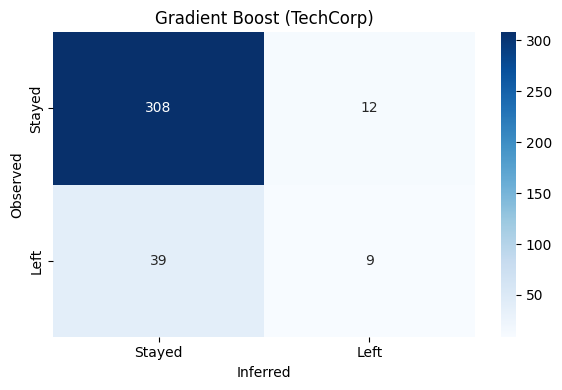

In [22]:
con = confusion_matrix(b_test, smart_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.xlabel('Inferred')
plt.ylabel('Observed')
plt.title('Gradient Boost (TechCorp)')
plt.tight_layout()
plt.show()

# **13.Feature Importance Analysis**
This bar graph is showing that the higher the bar, the more that feature contributes to the prediction of model.

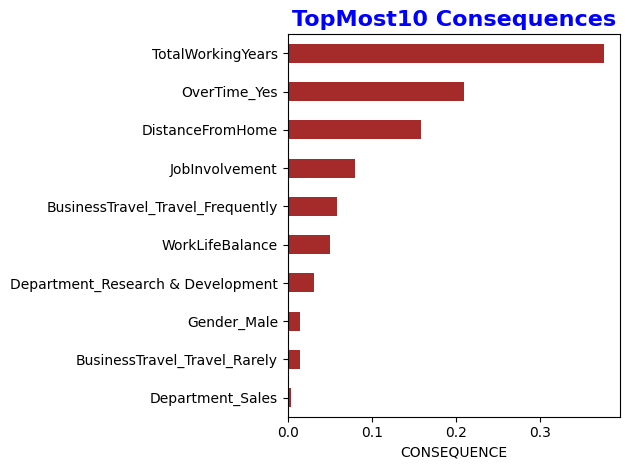

In [24]:
importances = pd.Series(smart_robot_team.feature_importances_, index=A.columns)
topmost10 = importances.sort_values(ascending=False).head(10)
importances.sort_values(ascending=False, inplace=True)
topmost10.sort_values().plot(kind='barh', color='brown')
plt.xlabel('CONSEQUENCE')
plt.title('TopMost10 Consequences', fontweight='bold', fontsize=16, color='blue')
plt.tight_layout()
plt.show()

# **⚖️14. Comparing Model Accuracy**
The presented step is comparison of accuracy of all models:
* **Overall Accuracy:** Bar chart that shows the accuracy percentage of each model, and so, one can simply determine the model that was the overall best.
* **F1-Score & Recall:** A grouped bar chart comparing the F1-Score and Recall of the Gradient Boosting and Random Forest with SMOTE models. This is where the importance of accuracy itself will be deceptive when it comes to uneven data, and why the balanced model is more practical when it comes to singling out potentially leaving employees.

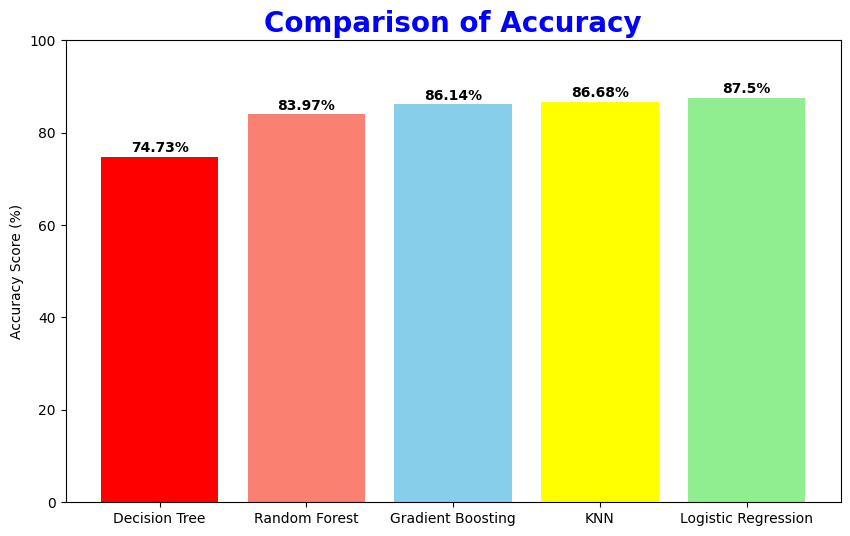

In [25]:
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN', 'Logistic Regression']
accuracy_scores = [
                    round(score* 100,2),
                    round(team_score * 100,2),
                    round(smart_score * 100,2),
                    round(knn_score * 100,2),
                    round(log_reg_score * 100,2)
                    ]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_scores, color=['red','salmon', 'skyblue', 'yellow', 'lightgreen'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', fontweight='bold')

plt.title('Comparison of Accuracy', fontsize=20, fontweight='bold', color='blue')
plt.ylabel('Accuracy Score (%)')
plt.ylim(0, 100)
plt.show()

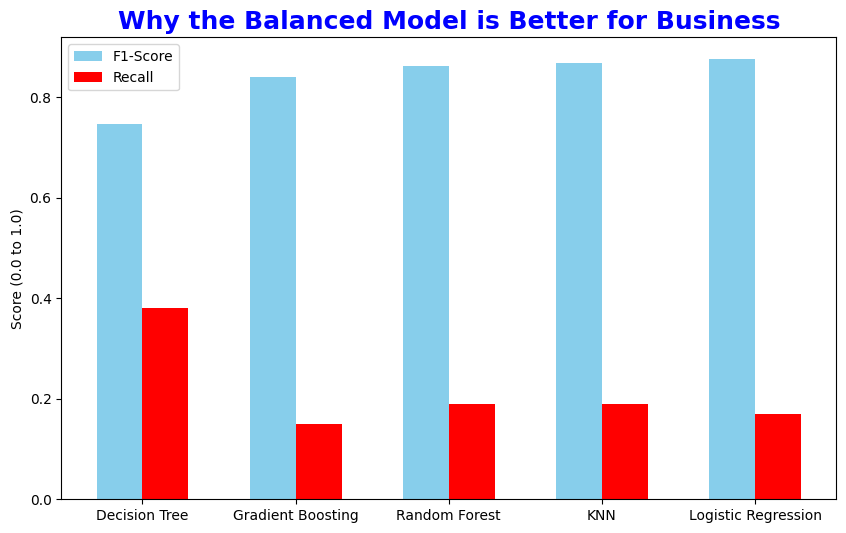

In [26]:
metrics = ['Decision Tree','Gradient Boosting', 'Random Forest', 'KNN', 'Logistic Regression']
f1_scores = [score, team_score, smart_score, knn_score, log_reg_score]
recall_scores = [0.38, 0.15,0.19, 0.19, 0.17]

x = range(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([p - width/2 for p in x], f1_scores, width, color='skyblue', label='F1-Score')
ax.bar([p + width/2 for p in x], recall_scores, width, color='red', label='Recall')

ax.set_ylabel('Score (0.0 to 1.0)')
ax.set_title('Why the Balanced Model is Better for Business', fontsize=18, fontweight='bold', color='blue')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

# **15.Strengths, Weaknesses and decision of Models**

* **Strengths:**
    * Several models offer a complete picture - simple decision tree (Decision Tree).
    * to powerful (Gradient Boosting)
    * both interpretability and accuracy are covered under models.
    * the feature importance shows the most driven attrition by the HR factors.

* **Weaknesses:**
    * Stronger models (Gradient Boosting, Random Forest) are more difficult.
    * to make sense to non-technical HR employees.
    * the data is not balanced - the models are more likely to predict "Stayed" more frequently.
    * findings are unlikely to be replicated in messy HR data.

* **TechCorp Use Case:**
    * Gradient Boosting will occur every month and identify the top 50 at-risk employees.
    * Logistic Regression makes predictions to HR managers easy to understand.
    * Importance of features informs HR policy - e.g. less overtime,
    * enhancing work-life balance amongst high-risk employees.

# **✅16.Final Decision for TechCorp**
# Primary Model of Recommendation: Gradient Boosting / Random Forest
**Gradient Boost** is the best prediction tool that should be used in TechCorp due to its effective accuracy in its monthly attrition-risk scoring system. The secondary engine, which should be used to communicate predictions to the business partners and management of the HR, is **Logistic Regression**, which is designed to have the ability of explainability.

# **Deployment Plan:**
* Run Gradient Boosting every month- result a list of first 50 at-risk person
* In HR dashboard- use the coefficients of Logistic Regression to define "which factors" are showing attrition
* HR business partners check the top 50 list and arrange one-on-one check-ins
* Expected Outcomes: 20% reduction in voluntary attrition, saving $300000-$500000 yearly in replacement

## **17. Ready for Deployment**

In [28]:
import joblib
joblib.dump(smart_robot_team, 'TechCorp Attrition Model.pkl')
joblib.dump(scaler, 'TechCorp_Attrition_Scaler.pkl')
print("Finally Pipeline Done!")

Finally Pipeline Done!
